# Parameter sweep for the 2D sheet

Copy of `4_sweep_parameters.ipynb` with `dim=2`. **Alpha and `velocity_gain` are still seeds — run this notebook
to refit them.** Do not copy `velocity_gain = 5` into `alpha`.

Each trial:

- Builds a network
- Lets a spatial lattice form
- Fits the velocity gain so bump speed matches the commanded speed
- Drives the network along a walk and scores how well the decoded bump tracks the true path

A score of 0 is perfect. A score of 1 means the tracking error is as large as the walk itself.
Networks with score 100 did not work


## 1. Setup
Ran in google colab so would need to be changed to run locally.


In [8]:
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys
import os

#!pip install -q optuna
import optuna

#%cd /content
#!rm -rf /content/CAN_Path_Integration_3D_model
#!git clone -b alpha-implementation --single-branch https://github.com/jacobsvennevik/CAN_Path_Integration_Plane_estimation_3D_model.git /content/CAN_Path_Integration_3D_model
#!pip install -q git+https://github.com/jacobsvennevik/MADE.git #Made from their own repo does not work. Did some changes and saved on my own githun
#%cd /content/CAN_Path_Integration_3D_model

sys.path.insert(0, os.path.abspath("../.."))

from config import RunConfig, NetworkConfig
from experiments.arena_3d import Arena3DExperiment, Arena3DConfig
from model.metrics import wrapped_angle_diff
from model.network.QAN3D import Torus3DQAN
from model.network.torch_backend import TorchBackend
from model.network.calibration import fit_gain
from model.network.visualize3D import (
    visualize_trajectory_projections, plot_bump_snapshots,
)


## 2. Set up the settings and the bounds for the search



In [9]:
# --- sheet ---
SPACING  = 0.1
DIM      = 2
DT       = 0.25
B        = 1.0

# --- walk ---
N_STEPS      = 10000
SEED         = 0
GRID_SPACING = 0.48          # metres per 2π wrap on the torus
TARGET_SPEED = 0.002         # rad per unit time (ExperimentConfig default)

# --- settle / calibrate (hardcoded; covers tau in [2, 8]) ---
SETTLE = 2000                # ceil(200·τ), 1600 at τ=8
BURN   = 400                 # 10 τ at the largest τ we search (8); ceil(10·τ/DT)=320 at τ=8

# --- known-good starting point. Alpha / vg are seeds to refit, not the number 5. ---
ALPHA            = 0.15      # loop gain ~1.7 at λ=1.0, ratio=1.05
LAMBDA_NET       = 1.0
RATIO            = 1.05
OFFSET_MAGNITUDE = 0.073     # ~9% of the 0.785 rad lattice period
TAU              = 5.0

# --- search bounds ---
ALPHA_LO,  ALPHA_HI  = 0.5, 4
LAMBDA_LO, LAMBDA_HI = 0.85,   1.4
RATIO_LO,  RATIO_HI  = 1.05,   3.0
OFFSET_LO, OFFSET_HI = 0.02,   0.25
TAU_LO,    TAU_HI    = 2.0,    8.0

# --- reject a trial if ---
FAIL               = 100.0
MIN_PEAKEDNESS     = 3.0     # max/mean activity
MIN_BUMPS          = 5.0     # a single blob has 1 bump per axis. We need more.
MIN_CELLS_PERIOD   = 8.0     # lattice must be resolved by enough cells
MAX_STEP_FRAC      = 0.5     # decoder jumped if one step > half a period (decoder track one bump)
RHO_MAX            = 0.15    # commanded speed vs. offset/tau
DL_MAX             = 0.20    # offset vs. kernel wavelength

# large strides: do not store every snapshot of the sheet
DRIVE_KW = dict(snapshot_stride=50_000, display_stride=2_000)


Build the experiment once, and generate the walk that every trial will be scored on.


[arena_3d] neurons 3,969 arena 2.0 m | grid_spacing 0.48 m | tilings 4.17


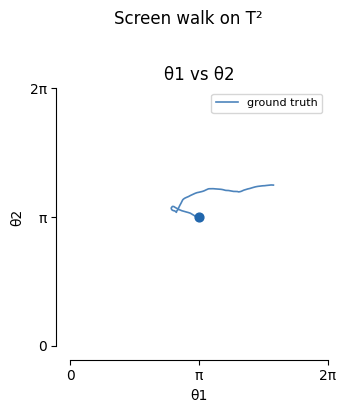

In [10]:
#Initate the config and experiment
config = RunConfig(
    network=NetworkConfig(
        build_connectivity=False, dt=DT, b=B, tau=TAU,
        spacing=SPACING, dim=DIM, lambda_net=LAMBDA_NET, ratio=RATIO,
        alpha=ALPHA, offset_magnitude=OFFSET_MAGNITUDE,
    ),
    experiment=Arena3DConfig(
        n_steps=N_STEPS, grid_spacing=GRID_SPACING,
        target_speed_rad_per_time=TARGET_SPEED, seed=SEED,
    ),
)
# torus_gt is sliced to d = DIM, so a T² sheet gets (N_STEPS, 2).
exp = Arena3DExperiment(config)
N = exp.qan.cans[0].nx(0)

_, _, ground_truth = exp.generate_trajectory(n_steps=N_STEPS, seed=SEED)
theta0 = ground_truth[0]

fig, _ = visualize_trajectory_projections(ground_truth, title="Screen walk on T²")
plt.show()


## 3. Score

Unwrap both paths

$$
\mathrm{score}
= \frac{\text{mean tracking error}}
        {\text{mean path length}}
$$

- **0** — decoded path matches ground truth
- **1** — error comparable to how far the animal walked


In [11]:
def unwrap(theta, period=2 * np.pi):
    """Turn wrapped torus coordinates into a continuous path."""
    step = wrapped_angle_diff(theta[1:], theta[:-1], period=period)
    return theta[0] + np.vstack([np.zeros((1, theta.shape[1])), np.cumsum(step, axis=0)])


def score(decoded, truth):
    dec_path = unwrap(decoded)
    gt_path = unwrap(truth)
    error = np.linalg.norm(dec_path - gt_path, axis=1)

    gt_step = wrapped_angle_diff(truth[1:], truth[:-1], period=2 * np.pi)
    path_length = np.concatenate([[0.0], np.cumsum(np.linalg.norm(gt_step, axis=1))])

    return float(error.mean() / path_length.mean())


## 4. One trial

For a proposed parameter set:

1. Cheap checks (`rho`, `delta/lambda`) — skip the expensive build if these fail
2. Build the network, settle, require a spatial lattice (peakedness, not a hard-coded hex shell)
3. Fit `velocity_gain`
4. Drive along the walk, reject decoder hops, return the score


In [12]:
def build(alpha, lambda_net, ratio, offset_magnitude, tau):
    return Torus3DQAN.from_config(NetworkConfig(
        spacing=SPACING, dim=DIM, alpha=alpha, b=B, tau=tau,
        lambda_net=lambda_net, ratio=ratio,
        offset_magnitude=offset_magnitude,
        dt=DT, velocity_gain=B * tau * 0.5, build_connectivity=False,  # raw gain ~2×; fit_gain refines
    ))


def objective(trial):
    backend = None
    try:
        alpha            = trial.suggest_float("alpha", ALPHA_LO, ALPHA_HI, log=True)
        lambda_net       = trial.suggest_float("lambda_net", LAMBDA_LO, LAMBDA_HI, log=True)
        ratio            = trial.suggest_float("ratio", RATIO_LO, RATIO_HI, log=True)
        offset_magnitude = trial.suggest_float("offset_magnitude", OFFSET_LO, OFFSET_HI)
        tau              = trial.suggest_float("tau", TAU_LO, TAU_HI, log=True)

        # speed the bump is asked to move relative to offset/tau
        rho = TARGET_SPEED * tau / offset_magnitude
        # offset relative to kernel wavelength
        dl  = offset_magnitude / lambda_net
        if rho > RHO_MAX or dl > DL_MAX:
            print(f"[trial {trial.number}] FAIL  rho={rho:.3f}  delta/lambda={dl:.3f}")
            return FAIL

        backend = TorchBackend(build(alpha, lambda_net, ratio, offset_magnitude, tau))
        #Peakedness is how bumpy the sheet is after settle. max activity / mean activity.
        #Checks for no activity at all
        peakedness = backend.form_lattice(theta0, settle=SETTLE, min_peakedness=0.0)
        period = float(backend.bump_period_cells())
        bumps  = N / period if period > 0 else 0.0
        #Calculates the wavevector of the strongest mode to determine if it is stripes or 3D lattices.
        k_vec, _ = backend.dominant_k()
        trial.set_user_attr("k", [float(v) for v in np.asarray(k_vec).ravel()])
        trial.set_user_attr("bumps", float(bumps))
        #Gates for no activity, too few bumps or too few cells per period.
        if not (peakedness >= MIN_PEAKEDNESS):    # NaN-safe: NaN >= 3.0 is False
            print(f"[trial {trial.number}] FAIL  no pattern (peakedness {peakedness:.2f})")
            return FAIL
        if bumps < MIN_BUMPS:
            print(f"[trial {trial.number}] FAIL  single blob (bumps/axis {bumps:.2f})")
            return FAIL
        if period < MIN_CELLS_PERIOD:
            print(f"[trial {trial.number}] FAIL  under-resolved ({period:.1f} cells/period)")
            return FAIL
        # Check how narrow the bumps are
        # bump width; needles sit near 0.002
        s = backend.S.mean(dim=0)
        frac_active = float((s > 0.5 * s.max()).float().mean())
        trial.set_user_attr("frac_active", frac_active)

        #Fits the velocity gain
        vg, g = fit_gain(backend, theta0, TARGET_SPEED, periods=2, burn=BURN)
        trial.set_user_attr("vg", float(vg) if np.isfinite(vg) else None)
        trial.set_user_attr("g",  float(g)  if np.isfinite(g)  else None)
        if not np.isfinite(vg):
            print(f"[trial {trial.number}] FAIL  gain calibration (g={g})")
            return FAIL

        decoded = backend.drive(ground_truth, **DRIVE_KW)
        #Checks for the decoder if it has jumped. (failure)
        step = wrapped_angle_diff(decoded[1:], decoded[:-1])
        max_step_cells = np.linalg.norm(step, axis=1).max() * (N / (2.0 * np.pi))
        if max_step_cells > MAX_STEP_FRAC * period:
            print(f"[trial {trial.number}] FAIL  tracker hop ({max_step_cells:.1f} cells)")
            return FAIL

        value = score(decoded, ground_truth)
        print(f"[trial {trial.number}] score={value:.4f}  "
              f"a={alpha:.4f}  L={lambda_net:.4f}  ratio={ratio:.3f}  "
              f"d={offset_magnitude:.4f}  tau={tau:.3f}  "
              f"pk={peakedness:.1f}  bumps={bumps:.1f} "
              f"frac={frac_active:.4f}  g={g:.3f} ")
        return value

    except Exception as e:
        print(f"[trial {trial.number}] FAIL  {e!r}")
        return FAIL
    finally:
        del backend
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


## 5. Run the sweep

Tree-structured Parzen Estimator (TPE) proposes new parameters from earlier scores.
The known-good point above is the first trial. The study is saved to SQLite so a Colab disconnect does not lose progress.


In [ ]:
sampler = optuna.samplers.TPESampler(seed=0, multivariate=True, n_startup_trials=40)
study = optuna.create_study(
    study_name="qan2d_screen",
    direction="minimize",
    storage="sqlite:///optuna_study.db",
    load_if_exists=True,
    sampler=sampler,
)
study.enqueue_trial({
    "alpha": ALPHA,
    "lambda_net": LAMBDA_NET,
    "ratio": RATIO,
    "offset_magnitude": OFFSET_MAGNITUDE,
    "tau": TAU,
})

t0 = time.time()
study.optimize(objective, n_trials=150, gc_after_trial=True, show_progress_bar=True)
print(f"{len(study.trials)} trials in {(time.time() - t0) / 60:.1f} min")
print("best:", study.best_value, study.best_params)


/Users/jacobhornsvennevik/anaconda3/envs/myenv/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-09-19 09:39:18,970] Using an existing study with name 'qan2d_screen' instead of creating a new one.


  0%|          | 0/150 [00:00<?, ?it/s]

/Users/jacobhornsvennevik/anaconda3/envs/myenv/lib/python3.11/site-packages/optuna/trial/_trial.py:652: UserWarning: Fixed parameter 'alpha' with value 0.15 is out of range for distribution FloatDistribution(high=4.0, log=True, low=0.5, step=None).
  warnings.warn(


[trial 7] FAIL  no pattern (peakedness 1.00)
[I 2026-09-19 09:39:24,101] Trial 7 finished with value: 100.0 and parameters: {'alpha': 0.15, 'lambda_net': 1.0, 'ratio': 1.05, 'offset_magnitude': 0.073, 'tau': 5.0}. Best is trial 0 with value: 100.0.
[trial 8] FAIL  single blob (bumps/axis 4.12)
[I 2026-09-19 09:39:29,384] Trial 8 finished with value: 100.0 and parameters: {'alpha': 1.5653014388703839, 'lambda_net': 1.2145264484110132, 'ratio': 1.9770078052479443, 'offset_magnitude': 0.14532313208928627, 'tau': 3.5982853486051414}. Best is trial 0 with value: 100.0.
[trial 9] FAIL  rho=0.028  delta/lambda=0.229
[I 2026-09-19 09:39:29,575] Trial 9 finished with value: 100.0 and parameters: {'alpha': 1.9154486356343403, 'lambda_net': 1.057421315823045, 'ratio': 2.6777936497116577, 'offset_magnitude': 0.24164243491523674, 'tau': 3.4031790038982583}. Best is trial 0 with value: 100.0.
[trial 10] FAIL  rho=0.019  delta/lambda=0.210
[I 2026-09-19 09:39:29,761] Trial 10 finished with value: 100

## 6. Best trials
Just show the best trails. Both score and the most amount of bumps.

In [ ]:
df = study.trials_dataframe()
df["k"] = df["user_attrs_k"] if "user_attrs_k" in df.columns else None
df["bumps"] = df["user_attrs_bumps"] if "user_attrs_bumps" in df.columns else np.nan
df["frac_active"] = df["user_attrs_frac_active"]
df["g"]           = df["user_attrs_g"]
# Removed 'mode' as it is not in the dataframe index
cols = [
    "number", "value", "bumps", "k", "frac_active","g",
    "params_alpha", "params_lambda_net", "params_ratio",
    "params_offset_magnitude", "params_tau",
]

# Sort by score
tbl = df[cols].sort_values("value")
n_fail = int((df["value"] >= FAIL).sum())
print(f"feasible: {int((df['value'] < FAIL).sum())}/{len(df)}")
display(tbl.head(15))

# Sort by bumps
tbl2 = df[cols].sort_values("bumps", ascending=False)
display(tbl2.head(15))

## 7. Longer walk

Rebuild the best network and score it on a longer walk than the sweep used. Seed 4, so this is not the screen trajectory. This is to compare our error against Burak and Fiete (2009), should be comparable.

In [ ]:
N_LONG = 10_000              # 5× the sweep walk
_, _, gt_long = exp.generate_trajectory(n_steps=N_LONG, seed=4)

backend = TorchBackend(build(**study.best_params))
pk = backend.form_lattice(gt_long[0], settle=SETTLE, min_peakedness=0.0)
vg, g = fit_gain(backend, gt_long[0], TARGET_SPEED, periods=2, burn=BURN)
snap_stride = max(1, N_LONG // 8)
decoded = backend.drive(
    gt_long, snapshot_stride=snap_stride, display_stride=DRIVE_KW["display_stride"])
value = score(decoded, gt_long)
bumps = N / backend.bump_period_cells()
print(f"score={value:.4f}  velocity_gain={vg:.4f}  g={g:.4f}  "
      f"pk={pk:.1f}  bumps={bumps:.1f}")





In [ ]:
fig, _ = visualize_trajectory_projections(
    gt_long, decoded, title="Longer walk, ground truth vs decoded")
plt.show()
fig, _ = plot_bump_snapshots(
    backend.snapshots, backend.snapshot_times,
    cells=backend.snapshot_cells,          # the ×
    radius=backend.tracker.radius,         # dashed window
    show_tracker=True)
plt.show()
